prueba 

In [1]:
#library import
import sqlite3
import pandas as pd
import geopandas as gpd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

In [2]:
#1. conect to db
con = sqlite3.connect('wells_data.db')
#read data into df
df = pd.read_sql_query('SELECT * FROM wells_data', con)
df
#2. save data into xlsx
#df.to_excel('wells_data.xlsx', index=False)

#eng = create_engine('sqlite:///wells_data.db')
#wells = pd.read_sql('wells_data', eng)

,index,wlbNpdidWellbore,dscNpdidDiscovery,fldNpdidField,fclNpdidFacilityDrilling,fclNpdidFacilityProducing,wlbNpdidWellboreReclass,prlNpdidProductionLicence,wlbWellboreName,wlbWell,...,wlbSubSea,wlbKickOffPoint,wlbLicenceTargetName,wlbPluggedDate,wlbPluggedAbandonDate,prlNpdidProdLicenceTarget,wlbNpdidSiteSurvey,wlbSiteSurvey,wlbDateReclass,wlbPointGeometryWKT
0,0,28,44990.0,NaN,288280.0,NaN,0,21348.0,7/8-3,7/8-3,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,POINT (2.5460499996279968 57.258494000193025)
1,1,30,NaN,NaN,287848.0,NaN,0,21356.0,7/11-8,7/11-8,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,POINT (2.5295830008933171 57.213871999628537)
2,2,42,44966.0,43792.0,287956.0,NaN,0,21356.0,7/11-5,7/11-5,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,POINT (2.4982029996618897 57.135107999856238)
3,3,57,23296230.0,43785.0,271693.0,NaN,0,20900.0,7/11-7,7/11-7,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,POINT (2.4346719996169637 57.069455999904839)
4,4,149,44960.0,43785.0,296407.0,NaN,0,20900.0,7/11-1,7/11-1,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,POINT (2.4401110006239985 57.070999999716726)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8243,8243,5743,NaN,NaN,289441.0,NaN,0,2490623.0,25/10-U-3,25/10-U-3,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,None
8244,8244,7685,NaN,NaN,373521.0,NaN,0,21559610.0,6306/5-U-1,6306/5-U-1,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,None
8245,8245,7810,NaN,NaN,289441.0,NaN,0,NaN,7934/6-U-3,7934/6-U-3,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,None
8246,8246,8412,NaN,NaN,461030.0,NaN,0,28942014.0,2/6-U-1,2/6-U-1,...,NO,0.0,NaN,None,None,NaN,NaN,None,None,None


In [3]:
df.columns.values

array(['index', 'wlbNpdidWellbore', 'dscNpdidDiscovery', 'fldNpdidField',
       'fclNpdidFacilityDrilling', 'fclNpdidFacilityProducing',
       'wlbNpdidWellboreReclass', 'prlNpdidProductionLicence',
       'wlbWellboreName', 'wlbWell', 'wlbDiscovery', 'wlbField',
       'wlbProductionLicence', 'wlbDrillPermit', 'wlbWellType',
       'wlbMultilateral', 'wlbWdssVolumeReference',
       'wlbLicensingActivity', 'wlbDrillingOperator',
       'wlbDrillingFacility', 'wlbFacilityTypeDrilling',
       'wlbProductionFacility', 'wlbEntryDate', 'wlbEntryDay',
       'wlbEntryMonth', 'wlbEntryYear', 'wlbCompletionDate',
       'wlbCompletionDay', 'wlbCompletionMonth', 'wlbCompletionYear',
       'wlbNsDeg', 'wlbNsMin', 'wlbNsSec', 'wlbEwDeg', 'wlbEwMin',
       'wlbEwSec', 'wlbNsDecDeg', 'wlbEwDesDeg', 'wlbGeodeticDatum',
       'wlbNsUtm', 'wlbEwUtm', 'wlbUtmZone', 'wlbEwCode', 'wlbNsCode',
       'wlbSeismicLocation', 'wlbPlotSymbol', 'wlbStatus', 'wlbContent',
       'wlbContentPlanned', 'wlbP

In [4]:
# 3. Wells data
# bottomhole temp = wlbBottomHoleTemperature
# Total depth = wlbTotalDepth

df[['wlbBottomHoleTemperature', 'wlbTotalDepth']]

,wlbBottomHoleTemperature,wlbTotalDepth
0,172.0,4320.0
1,148.0,4750.0
2,169.0,4478.0
3,168.0,4927.0
4,145.0,3974.0
...,...,...
8243,NaN,NaN
8244,NaN,NaN
8245,NaN,NaN
8246,NaN,NaN


Text(0.5, 1.0, 'Total depth vs Bottomhole Temperature')

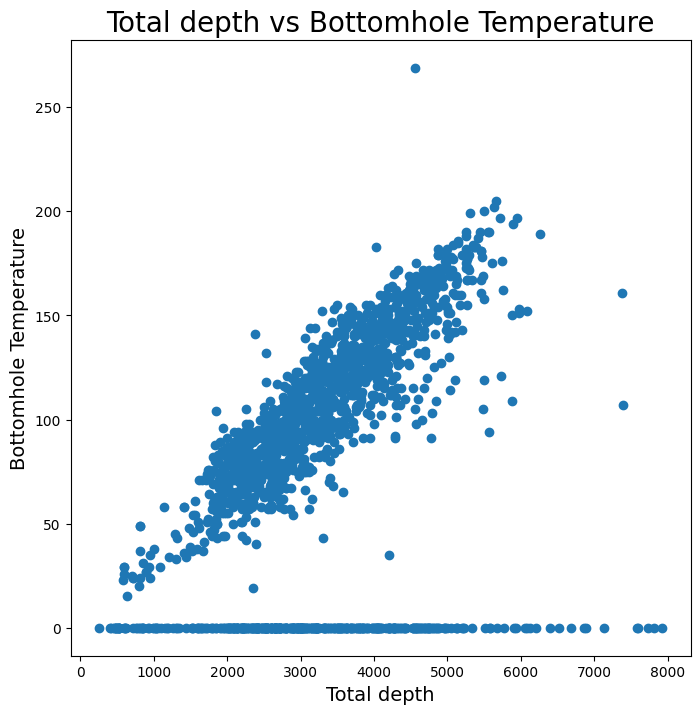

In [5]:
# 3.1.1 Make a scatter Plot of the bottom hole temperature (vertical axis) according to the total depth (horizontal axis) (with zero values)

x = df['wlbTotalDepth']
y = df['wlbBottomHoleTemperature']

plt.figure(figsize=(8,8))
plt.scatter(x, y)
plt.xlabel('Total depth', size = 14)
plt.ylabel('Bottomhole Temperature', size = 14)
plt.title("Total depth vs Bottomhole Temperature", size = 20)

#note= the units of temperature and total depht are missing from the raw data

Text(0.5, 1.0, 'Total depth vs Bottomhole Temperature')

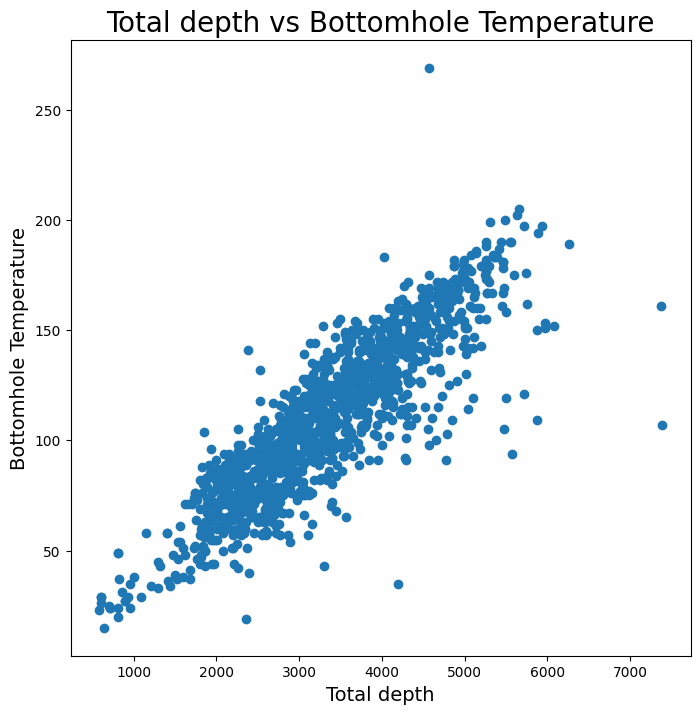

In [6]:
# 3.1.2 Make a scatter Plot of the bottom hole temperature (vertical axis) according to the total depth (horizontal axis) (without zero values)

x_filt = [p for p, t in zip(x,y) if t!=0]
y_filt = [t for t in y if t != 0]


len(x_filt) == len (y_filt)

#x = df['wlbTotalDepth']
#y = df['wlbBottomHoleTemperature']
plt.figure(figsize=(8,8))
plt.scatter(x_filt, y_filt)
plt.xlabel('Total depth', size = 14)
plt.ylabel('Bottomhole Temperature', size = 14)
plt.title("Total depth vs Bottomhole Temperature", size = 20)

#note= the units of temperature and total depht are missing from the raw data

Text(0.5, 1.0, 'Total depth vs Drilling Days')

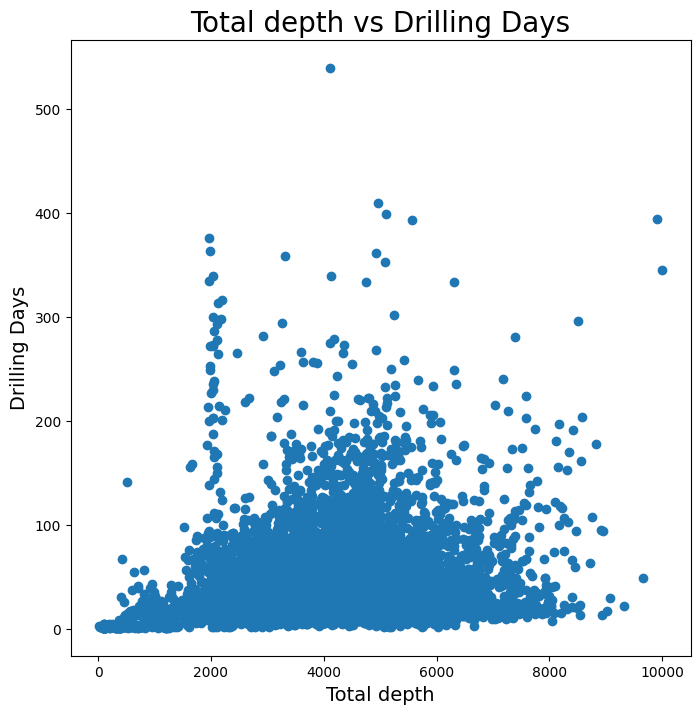

In [7]:
# 3.2 Make a scatter Plot of the drilling days (vertical axis) according to the total depth (horizontal axis); use query function to keep only 0 < wlbDrillingDays < 800

td = df['wlbTotalDepth']
days = df['wlbDrillingDays']

td_filt = [p for p,d  in zip(td,days) if 0 < d <800]
days_filt = [d for d in days if 0 < d<800]


len(td_filt) == len (days_filt)
plt.figure(figsize=(8,8))
plt.scatter(td_filt, days_filt)


plt.xlabel('Total depth', size = 14)
plt.ylabel('Drilling Days', size = 14)
plt.title("Total depth vs Drilling Days", size = 20)


In [8]:
# 3.3 Calculate the mean of the total depth according to the "Age At Td", show it as a table, sorted by mean total depth.!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

df[['wlbAgeAtTd', 'wlbTotalDepth']].groupby('wlbAgeAtTd', as_index=False). mean()



,wlbAgeAtTd,wlbTotalDepth
0,CAMPANIAN,3574.000000
1,CARBONIFEROUS,3368.500000
2,CRETACEOUS,4449.833333
3,DEVONIAN,4438.000000
4,EARLY CARBONIFEROUS,1767.666667
5,EARLY CRETACEOUS,3251.666667
6,EARLY JURASSIC,3631.920842
7,EARLY PERMIAN,3813.605714
8,EARLY TRIASSIC,3081.323529
9,EOCENE,2470.421053


In [9]:
#4. Production data:

#import openpyxl
import numpy as np

relative_piath = 'Volve_production_data.xlsx'
absolute_path = r'/Users/stephaniazambranoh/Desktop/GDM/python /Volve_production_data.xlsx'

dfprod = pd.read_excel(relative_path,sheet_name='Volve_production_data')
dfprod
#dfprod.columns.values

,Wellbore name,NPDCode,Year,Month,On Stream (hrs),Oil (Sm3),Gas (Sm3),Water (Sm3),GI (Sm3),WI (Sm3)
0,15/9-F-1 C,7405,2014,4,227.50000,11142.47,1597936.65,0.00,NaN,NaN
1,15/9-F-1 C,7405,2014,5,733.83334,24901.95,3496229.65,783.48,NaN,NaN
2,15/9-F-1 C,7405,2014,6,705.91666,19617.76,2886661.69,2068.48,NaN,NaN
3,15/9-F-1 C,7405,2014,7,742.41666,15085.68,2249365.75,6243.98,NaN,NaN
4,15/9-F-1 C,7405,2014,8,432.99166,6970.43,1048190.80,4529.75,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
521,15/9-F-5,5769,2016,5,732.00000,9724.40,1534677.16,3949.90,NaN,0.0
522,15/9-F-5,5769,2016,6,718.41667,9121.48,1468557.12,2376.93,NaN,NaN
523,15/9-F-5,5769,2016,7,668.64168,9985.29,1602674.39,2453.71,NaN,0.0
524,15/9-F-5,5769,2016,8,608.42500,8928.90,1417278.51,2371.86,NaN,0.0


In [10]:
# 4.1. Make a plot with the procution data (oil, gas and water) of the 7405 NPD code Volve according to the time.
#monthly column, create by concatenating the Year and the Month columns

year = dfprod['Year']
month = dfprod['Month']
dfprod['Monthly'] = year.astype(str) + '-' + month.astype(str).str.zfill(2)


#dfprod2 = dfprod.loc[['Monthly', 'Oil (Sm3)', 'Gas (Sm3)', 'Water (Sm3)']] 



dfprod['Monthly'] = pd.to_datetime(dfprod['Monthly'])

df_well_7405 = dfprod.loc[dfprod.NPDCode==7405]
df_well_7405
#dfprod.sort_values(by=['Monthly'], ascending=True)
#dfprod




,Wellbore name,NPDCode,Year,Month,On Stream (hrs),Oil (Sm3),Gas (Sm3),Water (Sm3),GI (Sm3),WI (Sm3),Monthly
0,15/9-F-1 C,7405,2014,4,227.50000,11142.47,1597936.65,0.00,NaN,NaN,2014-04-01
1,15/9-F-1 C,7405,2014,5,733.83334,24901.95,3496229.65,783.48,NaN,NaN,2014-05-01
2,15/9-F-1 C,7405,2014,6,705.91666,19617.76,2886661.69,2068.48,NaN,NaN,2014-06-01
3,15/9-F-1 C,7405,2014,7,742.41666,15085.68,2249365.75,6243.98,NaN,NaN,2014-07-01
4,15/9-F-1 C,7405,2014,8,432.99166,6970.43,1048190.80,4529.75,NaN,NaN,2014-08-01
5,15/9-F-1 C,7405,2014,9,630.30000,9168.43,1414099.99,8317.59,NaN,NaN,2014-09-01
6,15/9-F-1 C,7405,2014,10,745.00000,9468.06,1462063.99,10364.87,NaN,NaN,2014-10-01
7,15/9-F-1 C,7405,2014,11,579.77500,6710.33,1044188.30,7234.24,NaN,NaN,2014-11-01
8,15/9-F-1 C,7405,2014,12,27.50000,120.29,25857.08,183.44,NaN,NaN,2014-12-01
9,15/9-F-1 C,7405,2015,1,479.91667,10875.53,1604934.60,6850.80,NaN,NaN,2015-01-01


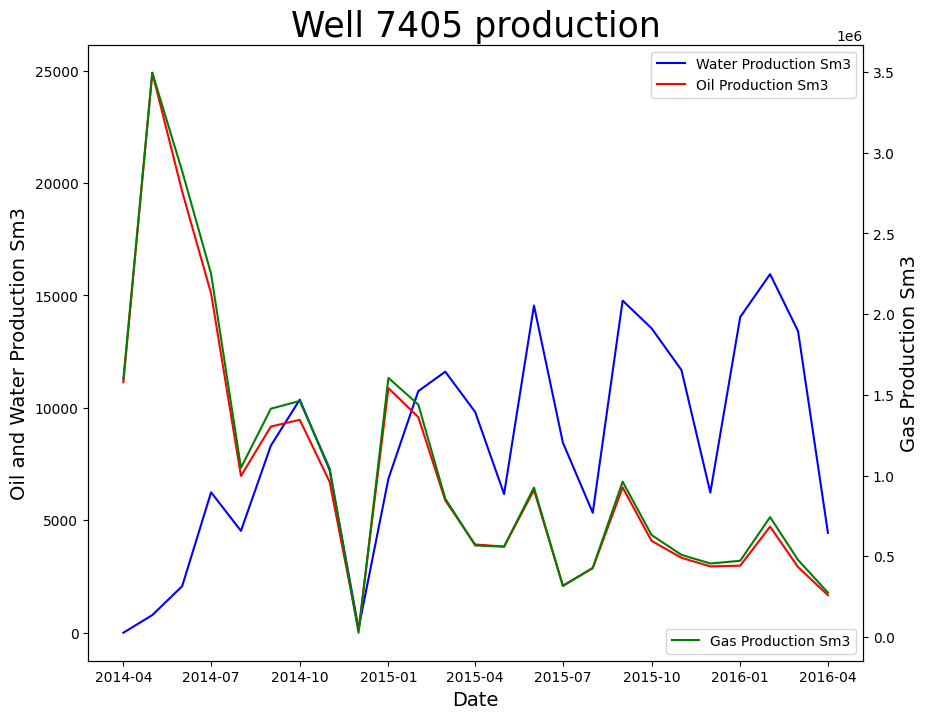

In [11]:
x = df_well_7405['Monthly']
y1 = df_well_7405['Oil (Sm3)']
y2 = df_well_7405['Gas (Sm3)'] 
y3 = df_well_7405['Water (Sm3)']

plt.figure(figsize=(10,8))

#plt.plot(x,y1,color = 'red')
#plt.plot(x,y3, color = 'blue')
#plt.plot(x,y2, color = 'green')

axes = plt.subplot()
#scale oil and water
axes.plot(x,y3, color='b', label = 'Water Production Sm3')
axes.set_xlabel('Date', size = 14)
axes.set_ylabel('Oil and Water Production Sm3', size = 14)
axes.plot(x,y1, color='r',label = 'Oil Production Sm3')
axes.set_xlabel('Date')
axes.legend()

#axes.set_yscale (value=1000)

#scale gas
twin_axes = axes.twinx() 
twin_axes.plot(x, y2, 'g',label = 'Gas Production Sm3')
twin_axes.set_ylabel('Gas Production Sm3', size = 14)
#twin_axes.set_yscale (value=1000000)
twin_axes.legend(loc='lower right')


plt.title("Well 7405 production", size = 25)

plt.show()
#type(y1[1])
#print(int(y1[1]))


In [12]:
# 4.2 Calculate the sum of the Oil production by Volve.
Oil_prod = dfprod['Oil (Sm3)'].sum()
print ('The total value of oil production is: ', Oil_prod, 'Sm3')

The total value of oil production is:  10037080.61 Sm3


In [13]:
# 5.Merged Data 
# 5.1. Create 2 new dataframes:
# 5.1.1. partial_wells_data from wells_data by keeping only wlbTotalDepthcolumns and the common columns

#'wlbNpdidWellbore', 'wlbTotalDepth'

partial_wells_data= df[['wlbNpdidWellbore', 'wlbTotalDepth']]

partial_wells_data


,wlbNpdidWellbore,wlbTotalDepth
0,28,4320.0
1,30,4750.0
2,42,4478.0
3,57,4927.0
4,149,3974.0
...,...,...
8243,5743,NaN
8244,7685,NaN
8245,7810,NaN
8246,8412,NaN


In [14]:
# 5.1.2. partial_mpd from monthly_production_data (mpd) by keeping only Oil, Gas Water and the common column
# 'NPDCode'

partial_mpd = dfprod[['NPDCode', 'Oil (Sm3)',	'Gas (Sm3)','Water (Sm3)']]
partial_mpd


,NPDCode,Oil (Sm3),Gas (Sm3),Water (Sm3)
0,7405,11142.47,1597936.65,0.00
1,7405,24901.95,3496229.65,783.48
2,7405,19617.76,2886661.69,2068.48
3,7405,15085.68,2249365.75,6243.98
4,7405,6970.43,1048190.80,4529.75
...,...,...,...,...
521,5769,9724.40,1534677.16,3949.90
522,5769,9121.48,1468557.12,2376.93
523,5769,9985.29,1602674.39,2453.71
524,5769,8928.90,1417278.51,2371.86


In [15]:
# 5.2 Merge both dataframes as merged_data
merge_data = partial_wells_data.merge(partial_mpd, left_on='wlbNpdidWellbore', right_on='NPDCode').groupby('NPDCode', as_index=False).sum()

merge_data

,NPDCode,wlbNpdidWellbore,wlbTotalDepth,Oil (Sm3),Gas (Sm3),Water (Sm3)
0,5351,556504,390000.0,3942233.39,5.780095e+08,7121249.74
1,5599,582296,366080.0,4579609.55,6.675423e+08,6833320.37
2,5693,637616,393120.0,0.00,0.000000e+00,0.00
3,5769,628821,413328.0,41160.68,6.561826e+06,13533.18
4,7078,276042,177918.0,1147849.10,1.743105e+08,1090806.27
5,7289,240537,154605.0,148518.56,2.250535e+07,52366.40
6,7405,185125,102350.0,177709.33,2.644092e+07,207302.39


Text(0.5, 1.0, 'Total depth vs Oil production')

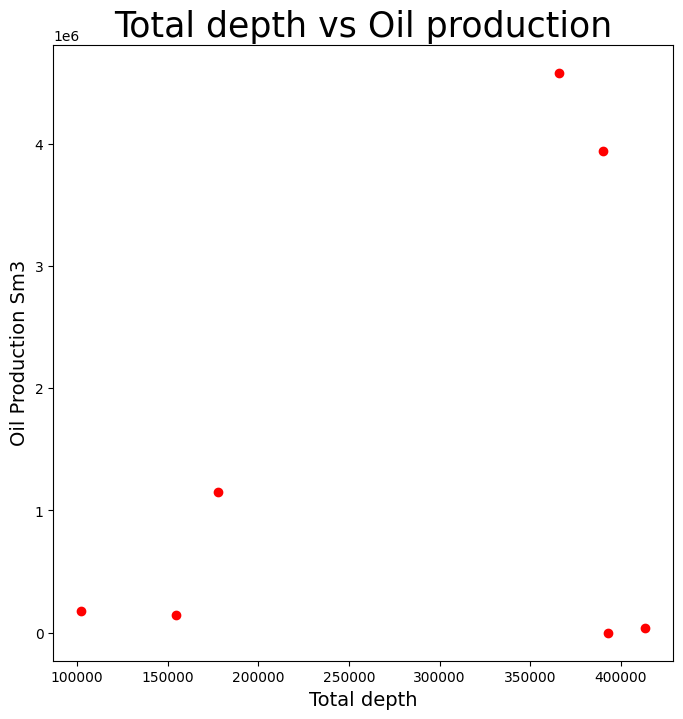

In [16]:
#5.3. Make a scatter plot of the oil production (vertical axis) according to the total depth (horizontal axis). Is there a correlation between the depth and the production?

x = merge_data['wlbTotalDepth']
y = merge_data['Oil (Sm3)']

plt.figure(figsize=(8,8))

plt.scatter(x,y,color='r')
plt.xlabel('Total depth', size = 14)
plt.ylabel('Oil Production Sm3', size = 14)


plt.title("Total depth vs Oil production", size = 25)